In [98]:
# Load standard modules
import numpy as np
from matplotlib import pyplot as plt

# Load tudatpy modules
from tudatpy.interface import spice
from tudatpy import dynamics
from tudatpy.dynamics import environment_setup, propagation_setup, simulator
from tudatpy.astro import element_conversion
from tudatpy import constants
from tudatpy.util import result2array
from tudatpy.astro.time_representation import DateTime

In [99]:
# Load spice kernels
spice.load_standard_kernels()

# Set simulation start and end epochs
simulation_start_epoch = DateTime(2000, 1, 1).to_epoch()
simulation_end_epoch   = DateTime(2001, 1, 1).to_epoch()

In [100]:
# Create default body settings for "Sun"
bodies_to_create = ["Sun", "Mercury", "Venus", "Earth", "Mars", "Jupiter", "Saturn"]

# Create default body settings for bodies_to_create, with "Sun"/"J2000" as the global frame origin and orientation
global_frame_origin = "Sun"
global_frame_orientation = "J2000"
body_settings = environment_setup.get_default_body_settings(
    bodies_to_create, global_frame_origin, global_frame_orientation)

In [101]:
# Add empty settings to body settings
body_settings.add_empty_settings("Asteroid")

In [102]:
# Create system of bodies (in this case only Earth)
bodies = environment_setup.create_system_of_bodies(body_settings)

In [103]:
# Define bodies that are propagated
bodies_to_propagate = ["Asteroid"]

# Define central bodies of propagation
central_bodies = ["Sun"]

In [104]:
# Define accelerations acting on Asteroid
acceleration_settings_asteroid = dict(
    Sun=[propagation_setup.acceleration.point_mass_gravity(),
         propagation_setup.acceleration.relativistic_correction()
    ],
    #Spherical didnt work, chatgpt recommended point mass, with relativistic correction
    Mercury=[
        propagation_setup.acceleration.point_mass_gravity()
    ],
    Venus=[
        propagation_setup.acceleration.point_mass_gravity()
    ],
    Earth=[
        propagation_setup.acceleration.point_mass_gravity()
    ],
    Mars=[
        propagation_setup.acceleration.point_mass_gravity()
    ],
    Jupiter=[
        propagation_setup.acceleration.point_mass_gravity()
    ],
    Saturn=[
        propagation_setup.acceleration.point_mass_gravity()
    ]
)

acceleration_settings = {"Asteroid": acceleration_settings_asteroid}

# Create acceleration models
acceleration_models = propagation_setup.create_acceleration_models(
    bodies, acceleration_settings, bodies_to_propagate, central_bodies
)

In [105]:
# Set initial conditions for the satellite that will be
# propagated in this simulation. The initial conditions are given in
from tudatpy.data.horizons import HorizonsQuery

target_horizons = 66146;

sun_gravitational_parameter = bodies.get("Sun").gravitational_parameter
hypatia_horizons_query = HorizonsQuery(
    query_id=target_horizons,
    location="@Sun",
    epoch_start=simulation_start_epoch,
    epoch_end=simulation_end_epoch,
    epoch_step="1d",
    extended_query=True,
)
#I used https://ssd.jpl.nasa.gov/horizons/app.html#/

In [106]:
jpl_observations = hypatia_horizons_query.interpolated_observations()
jpl_RA = jpl_observations[:, 1]
jpl_DEC = jpl_observations[:, 2]

In [107]:
jpl_vector = hypatia_horizons_query.cartesian()
#This gives the x,y,z,vx,vy,vz vector (with time in front)

In [108]:
initial_state = jpl_vector[0][1:7]
#print(jpl_vector[0][1:7])

In [109]:
# Create termination settings
termination_settings = propagation_setup.propagator.time_termination(simulation_end_epoch)

# Create numerical integrator settings
integrator_settings = propagation_setup.integrator.runge_kutta_fixed_step(
    time_step = 86400.0,
    coefficient_set = propagation_setup.integrator.CoefficientSets.rk_4 )

# Create propagation settings
propagator_settings = propagation_setup.propagator.translational(
    central_bodies,
    acceleration_models,
    bodies_to_propagate,
    initial_state,
    simulation_start_epoch,
    integrator_settings,
    termination_settings
)

In [110]:
# Create simulation object and propagate the dynamics
dynamics_simulator = simulator.create_dynamics_simulator(
    bodies, propagator_settings
)
# Extract the resulting state history and convert it to an ndarray
states = dynamics_simulator.propagation_results.state_history
states_array = result2array(states)

In [111]:
print(
    f"""
Single Sun-Orbiting Asteroid Example.
The initial position vector of TU3 1998 is [km]: \n{
    states[simulation_start_epoch][:3] / 1E3}
The initial velocity vector of TU3 1998 is [km/s]: \n{
    states[simulation_start_epoch][3:] / 1E3}
\nAfter {simulation_end_epoch} seconds the position vector of TU3 1998 is [km]: \n{
    states[simulation_end_epoch][:3] / 1E3}
And the velocity vector of TU3 1998 is [km/s]: \n{
    states[simulation_end_epoch][3:] / 1E3}
    """
)


Single Sun-Orbiting Asteroid Example.
The initial position vector of TU3 1998 is [km]: 
[ 48083348.27889542 -96378178.13376346  -2488428.0035573 ]
The initial velocity vector of TU3 1998 is [km/s]: 
[36.38566462 -1.29843144 -3.33888482]

After 31622400.0 seconds the position vector of TU3 1998 is [km]: 
[ 1.61716102e+08  5.45089143e+07 -1.60660942e+07]
And the velocity vector of TU3 1998 is [km/s]: 
[-9.97630485 17.93707391  0.55903006]
    


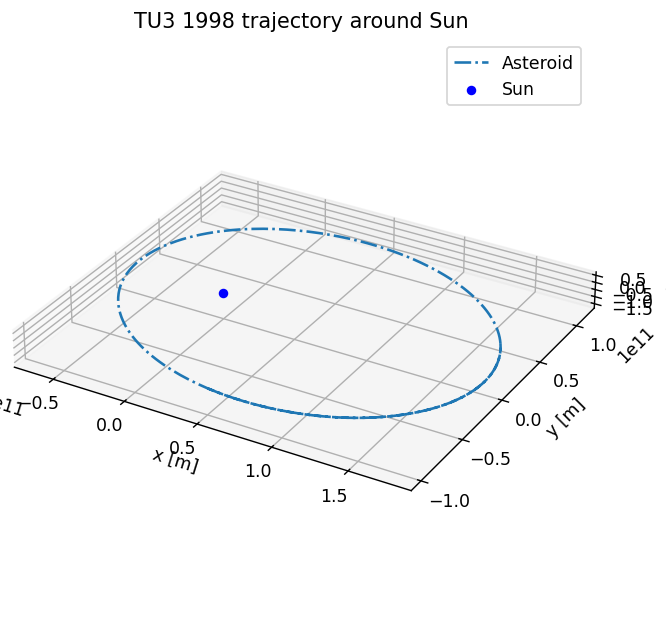

In [112]:
# Define a 3D figure using pyplot
fig = plt.figure(figsize=(6,6), dpi=125)
ax = fig.add_subplot(111, projection='3d')
ax.set_title(f'TU3 1998 trajectory around Sun')

# Plot the positional state history
ax.plot(states_array[:, 1], states_array[:, 2], states_array[:, 3], label=bodies_to_propagate[0], linestyle='-.')
ax.scatter(0.0, 0.0, 0.0, label="Sun", marker='o', color='blue')

# Add the legend and labels, then show the plot
ax.legend()
ax.set_xlabel('x [m]')
ax.set_ylabel('y [m]')
ax.set_zlabel('z [m]')
ax.set_aspect('equal')
plt.show()

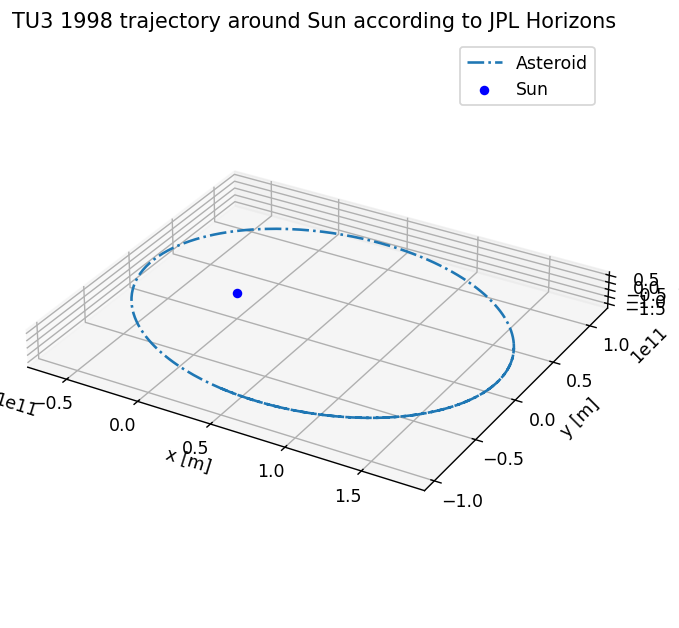

In [113]:
fig = plt.figure(figsize=(6,6), dpi=125)
ax = fig.add_subplot(111, projection='3d')
ax.set_title(f'TU3 1998 trajectory around Sun according to JPL Horizons')

# Plot the positional state history
ax.plot(jpl_vector[:, 1], jpl_vector[:, 2], jpl_vector[:, 3], label=bodies_to_propagate[0], linestyle='-.')
ax.scatter(0.0, 0.0, 0.0, label="Sun", marker='o', color='blue')

# Add the legend and labels, then show the plot
ax.legend()
ax.set_xlabel('x [m]')
ax.set_ylabel('y [m]')
ax.set_zlabel('z [m]')
ax.set_aspect('equal')
plt.show()

In [114]:
#The difference between the propogated/integrated orbit and the one JPL found
print(max(((states_array[:,1]-jpl_vector[:,1])/1.496e11)))
print(max((states_array[:,2]-jpl_vector[:,2])/1.496e11))
print(max((states_array[:,3]-jpl_vector[:,3])/1.496e11))
#print((states_array[:,1]-jpl_vector[:,1])/1.496e11)
#print((states_array[:,2]-jpl_vector[:,2])/1.496e11)
#print((states_array[:,3]-jpl_vector[:,3])/1.496e11)

6.834344287046137e-05
7.188967026893468e-05
1.772648908237085e-05


In [115]:

print(max(states_array[:,1])/1.496e11,
      max(states_array[:,2])/1.496e11,
      max(states_array[:,3])/1.496e11)
print(max(jpl_vector[:,1])/1.496e11,
      max(jpl_vector[:,2])/1.496e11,
      max(jpl_vector[:,3])/1.496e11)

1.1589830428427141 0.7357903024268726 0.03838481632697559
1.1589829140643098 0.7357970571654973 0.03838363385316082


In [134]:
#spice.get_body_cartesian_state_at_epoch() to get planet orbits??

In [135]:
#spice.get_body_cartesian_state_at_epoch(
#    target_body_name="Earth",
#    observer_body_name="Sun",
#    reference_frame_name="J2000",
#    aberration_corrections="NONE",
#    ephemeris_time=simulation_start_epoch)

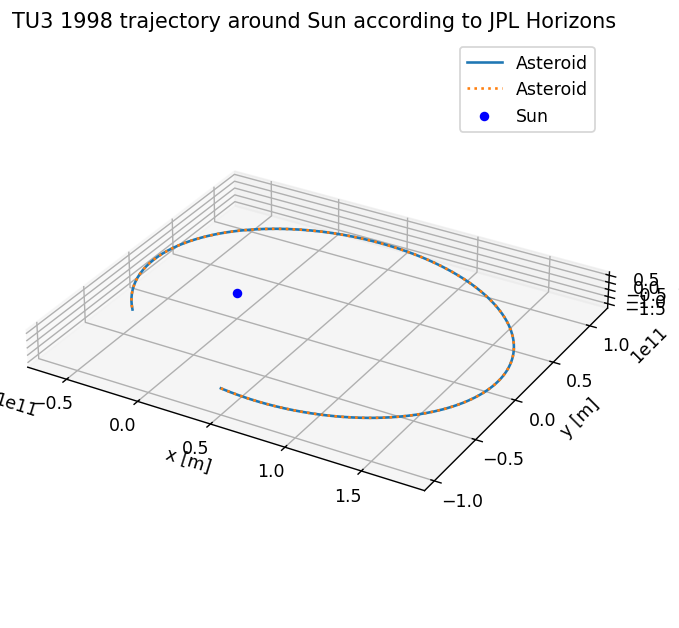

In [132]:
fig = plt.figure(figsize=(6,6), dpi=125)
ax = fig.add_subplot(111, projection='3d')
ax.set_title(f'TU3 1998 trajectory around Sun according to JPL Horizons')

# Plot the positional state history
ax.plot(states_array[:230, 1], states_array[:230, 2], states_array[:230, 3], label=bodies_to_propagate[0])
ax.plot(jpl_vector[:230, 1], jpl_vector[:230, 2], jpl_vector[:230, 3], label=bodies_to_propagate[0], linestyle='dotted')
ax.scatter(0.0, 0.0, 0.0, label="Sun", marker='o', color='blue')

# Add the legend and labels, then show the plot
ax.legend()
ax.set_xlabel('x [m]')
ax.set_ylabel('y [m]')
ax.set_zlabel('z [m]')
ax.set_aspect('equal')
plt.show()

In [133]:
print(states_array[230,1]/1.496e11,
      states_array[230,2]/1.496e11,
      states_array[230,3]/1.496e11)
print(jpl_vector[230,1]/1.496e11,
      jpl_vector[230,2]/1.496e11,
      jpl_vector[230,3]/1.496e11)

-0.24202246559056675 -0.39365697328999966 0.030376242868006786
-0.24207569935260445 -0.39362383491762826 0.030387003624978065
